#### Import pandas and matplotlib

In [402]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


#### Read CSV file

In [173]:
df = pd.read_csv('bmw.csv')

**Make columns lower names case and strip off white spaces to avoid errors**

In [174]:
df.columns = df.columns.str.lower().str.strip()

** Remove unwanted columns **

In [176]:
df = df.drop(columns=[
    'unnamed: 12',
    'unnamed: 13',
    'unnamed: 14',
    'unnamed: 15',
    'unnamed: 16'
    ])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   model                 50000 non-null  str    
 1   year                  50000 non-null  int64  
 2   region                50000 non-null  str    
 3   color                 50000 non-null  str    
 4   fuel_type             50000 non-null  str    
 5   transmission          50000 non-null  str    
 6   engine_size_l         50000 non-null  float64
 7   mileage_km            50000 non-null  str    
 8   price_usd             50000 non-null  str    
 9   sales_volume          50000 non-null  int64  
 10  revenue               50000 non-null  str    
 11  sales_classification  50000 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 4.6 MB


**Remove Extra white spaces from all columns**

In [177]:

df.select_dtypes(include=['object', 'string']).apply(lambda x: x.str.strip())


,model,region,color,fuel_type,transmission,mileage_km,price_usd,revenue,sales_classification
0,5 Series,Asia,Red,Petrol,Manual,"151,748.00","$98,740.00","$819,542,000.00",High
1,i8,North America,Red,Hybrid,Automatic,"121,671.00","$79,219.00","$271,562,732.00",Low
2,5 Series,North America,Blue,Petrol,Automatic,"10,991.00","$113,265.00","$792,175,410.00",Low
3,X3,Middle East,Blue,Petrol,Automatic,"27,255.00","$60,971.00","$246,749,637.00",Low
4,7 Series,South America,Black,Diesel,Manual,"122,131.00","$49,898.00","$153,685,840.00",Low
...,...,...,...,...,...,...,...,...,...
49995,i3,Asia,Red,Hybrid,Manual,"151,030.00","$42,932.00","$351,269,624.00",High
49996,i3,Middle East,Silver,Electric,Manual,"147,396.00","$48,714.00","$478,176,624.00",High
49997,5 Series,Middle East,Red,Petrol,Automatic,"174,939.00","$46,126.00","$381,923,280.00",High
49998,i3,Asia,White,Electric,Automatic,"3,379.00","$58,566.00","$555,557,076.00",High


**Clean up the Price column. remove the dollar sign, remove the .00 at the end, remove coma and convert to string**

In [178]:
#create a function for them all
def clean_ints(cols):
    df[cols] = df[cols].str.replace('.00', '').str.replace('$', '').str.replace(',', '')
    df[cols] = df[cols].astype(int)

    return df.head(2)


In [179]:
clean_ints('revenue')
clean_ints('price_usd')
clean_ints('mileage_km')

,model,year,region,color,fuel_type,transmission,engine_size_l,mileage_km,price_usd,sales_volume,revenue,sales_classification
0,5 Series,2016,Asia,Red,Petrol,Manual,4,151748,98740,8300,819542000,High
1,i8,2013,North America,Red,Hybrid,Automatic,2,121671,79219,3428,271562732,Low


In [180]:
chart_color = '#0543a6'

**Group Sales volume by models**

In [181]:
sales_grp = df.groupby('model')['sales_volume'].sum().reset_index().sort_values(by='sales_volume', ascending=False)
sales_grp


,model,sales_volume
2,7 Series,23786466
10,i8,23423891
5,X1,23406060
0,3 Series,23281303
9,i3,23133849
1,5 Series,23097519
4,M5,22779688
6,X3,22745529
7,X5,22709749
8,X6,22661986


In [182]:
#Total Sales
Total_sales = df['sales_volume'].sum()
print(f' Total Sales: {Total_sales:,.2f} \n Two hundred fifty-three million, three hundred seventy-five thousand, seven hundred thirty-four.')


 Total Sales: 253,375,734.00 
 Two hundred fifty-three million, three hundred seventy-five thousand, seven hundred thirty-four.


**Group Revenue by Models**

In [183]:

revenue_grp = df.groupby('model')['revenue'].sum().reset_index().sort_values(by='revenue', ascending=False)
# revenue_grp['revenue'].apply(lambda x: f'{x:,.2f}')
revenue_grp


,model,revenue
2,7 Series,1790070249282
0,3 Series,1768534028214
10,i8,1764743448529
5,X1,1752985285361
1,5 Series,1735712423092
9,i3,1724197530210
7,X5,1708653383772
6,X3,1707951188482
4,M5,1698467355916
8,X6,1693423254979


In [184]:
# Total Revenues
Total_revenue = df['revenue'].sum()
print(f'Total Revenue: {Total_revenue:,.2f} \n Nineteen trillion, twelve billion, two hundred forty-two million, five hundred thirty-four thousand, four hundred fifty-nine.')

Total Revenue: 19,012,242,534,459.00 
 Nineteen trillion, twelve billion, two hundred forty-two million, five hundred thirty-four thousand, four hundred fifty-nine.


**create two plots in same fig for revenue by models and Sales volume by models**

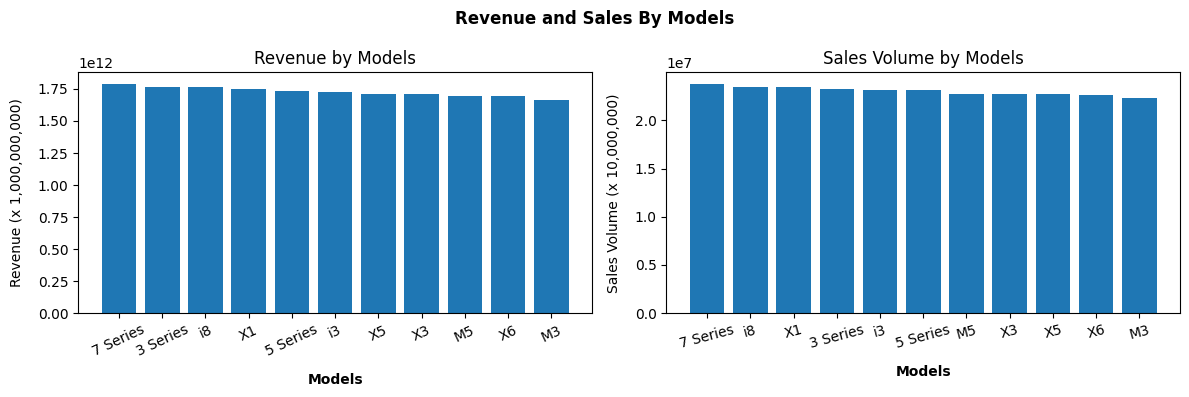

In [293]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
fig.suptitle("Revenue and Sales By Models", fontweight='bold')
                       
ax[0].bar(revenue_grp['model'], revenue_grp['revenue'])
ax[0].set_title("Revenue by Models")
ax[0].set_ylabel("Revenue (x 1,000,000,000)", labelpad=10)
ax[0].tick_params(axis='x', rotation=25)
ax[0].set_xlabel("Models", labelpad=10, fontweight='bold')
ax[1].bar(sales_grp['model'], sales_grp['sales_volume'])
ax[1].set_title('Sales Volume by Models')
ax[1].tick_params(axis='x', rotation=15)
ax[1].set_xlabel("Models", labelpad=10, fontweight='bold')
ax[1].set_ylabel("Sales Volume (x 10,000,000)", labelpad=10)
fig.tight_layout()


**Calculate Revenue and sales by Year.**

In [245]:
yearly_trends = df.groupby('year')[['revenue', 'sales_volume']].sum().sort_values(by='revenue', ascending=False).reset_index()
yearly_trends['year'].astype(str)
yearly_trends



,year,revenue,sales_volume
0,2022,1344427738820,17920946
1,2024,1312808115466,17527854
2,2019,1289342744664,17191956
3,2016,1284641854435,16957550
4,2021,1272402559079,16884666
5,2014,1269989867142,16958960
6,2010,1261631480830,16933445
7,2011,1258944308614,16758941
8,2013,1258599026870,16866733
9,2012,1257840248199,16751895


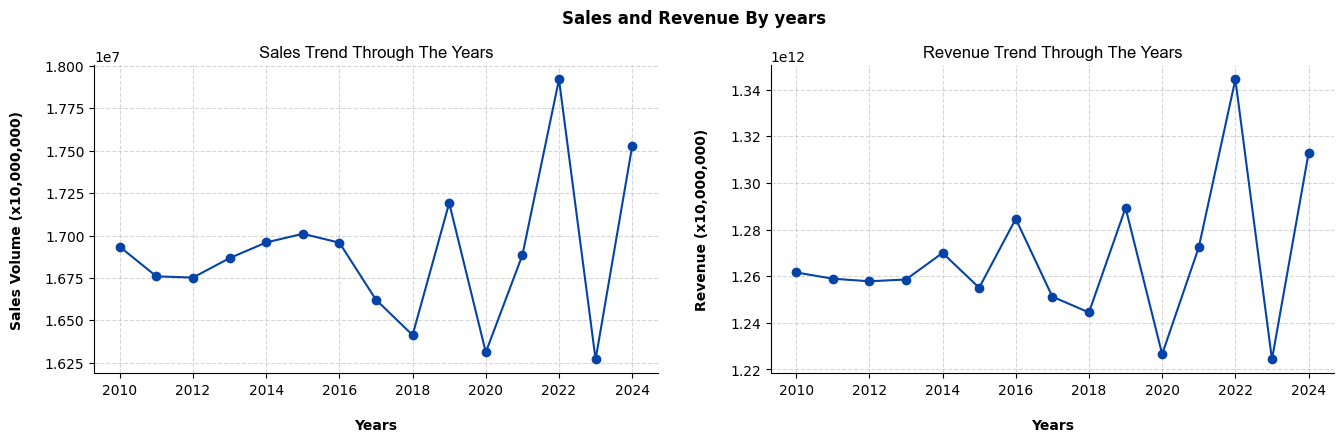

In [303]:
yearly_trends = yearly_trends.sort_values(by='year')
fig, ax = plt.subplots(1, 2, figsize=(16,4))
plt.suptitle('Sales and Revenue By years', fontweight='bold', y=1.02)

ax[1].plot(yearly_trends['year'], yearly_trends['revenue'],
           marker='o',
           linestyle='-',
           color=chart_color)

ax[0].plot(yearly_trends['year'], yearly_trends['sales_volume'], 
            marker='o',
           linestyle='-',
           color=chart_color)
ax[1].set_title('Revenue Trend Through The Years', fontname='arial')
ax[0].set_title('Sales Trend Through The Years', fontname='arial')


ax[0].set_ylabel("Sales Volume (x10,000,000)", labelpad=15, fontweight='bold')
ax[1].set_ylabel("Revenue (x10,000,000)", labelpad=15, fontweight='bold')

for chart in ax:
    chart.spines[['top','right']].set_visible(False)
    chart.grid(True, linestyle='--', alpha=0.5)
    chart.set_xlabel("Years", labelpad=15, fontweight='bold')
    chart.set_xlabel("Years", labelpad=15, fontweight='bold')
  
plt.show()

CHECKING YEAR ON YEAR REVENUE GROWTH

In [ ]:
yearly_trends['year'] = yearly_trends['year'].astype(int)
yearly_trends = yearly_trends.reset_index(drop=True)
yearly_trends['prev_yr_rev'] = yearly_trends['revenue'].shift(1)
yearly_trends = yearly_trends.fillna('0')
yearly_trends['prev_yr_rev'] = yearly_trends['prev_yr_rev'].astype(int)
yearly_trends['rev_growth'] = yearly_trends['revenue'] - yearly_trends['prev_yr_rev']
yearly_trends.loc[0, 'rev_growth'] = 0
yearly_trends['(%) Growth'] = round((100 * yearly_trends['rev_growth']) / yearly_trends['revenue'], 2)

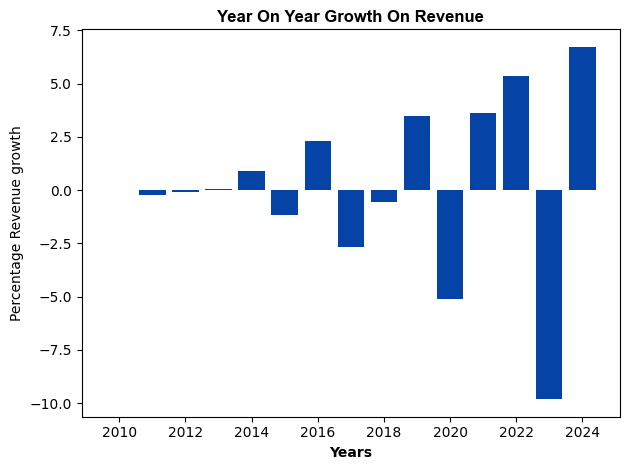

In [292]:
plt.bar(yearly_trends['year'], yearly_trends['(%) Growth'], color=chart_color)
plt.title("Year On Year Growth On Revenue",
          fontweight = 'bold',
          pad=5,
          fontname= 'Arial')
plt.xlabel('Years', fontweight='bold')
plt.ylabel('Percentage Revenue growth')
plt.tight_layout()
plt.show()

**Calculate Year on year Sales Growth**

In [288]:
yearly_trends['prev_yr_sales'] = yearly_trends['sales_volume'].shift(1)
yearly_trends['prev_yr_sales'] = yearly_trends['prev_yr_sales'].fillna(0)

yearly_trends['prev_yr_sales'] = yearly_trends['prev_yr_sales'].astype(int)
yearly_trends['sales_growth'] = yearly_trends['sales_volume'] - yearly_trends['prev_yr_sales']
yearly_trends.loc[0, 'sales_growth'] = 0
yearly_trends['pcnt Growth'] = round((100 * yearly_trends['sales_growth']) / yearly_trends['sales_volume'], 2)

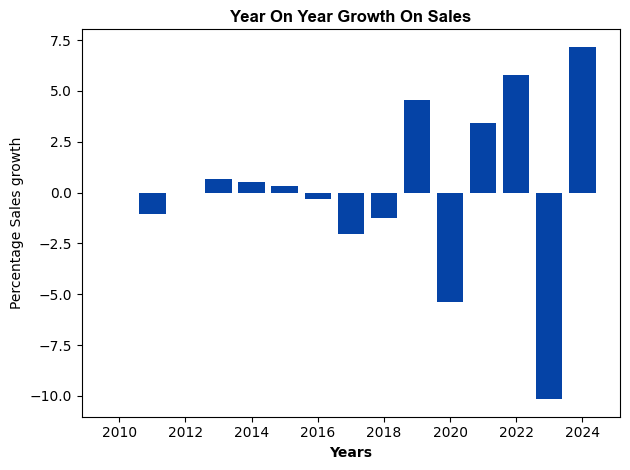

In [291]:
plt.bar(yearly_trends['year'], yearly_trends['pcnt Growth'], color=chart_color)
plt.title("Year On Year Growth On Sales",
          fontweight = 'bold',
          pad=5,
          fontname= 'Arial')
plt.xlabel('Years', fontweight='bold')
plt.ylabel('Percentage Sales growth')
plt.tight_layout()
plt.show()

## Regional Analysis

In [309]:
region_data = df.groupby('region')[['revenue', 'sales_volume']].sum().reset_index()
region_data

,region,revenue,sales_volume
0,Africa,3108999419352,41565252
1,Asia,3250635961348,42974277
2,Europe,3188079573212,42555138
3,Middle East,3167783530851,42326620
4,North America,3182938635076,42402629
5,South America,3113805414620,41551818


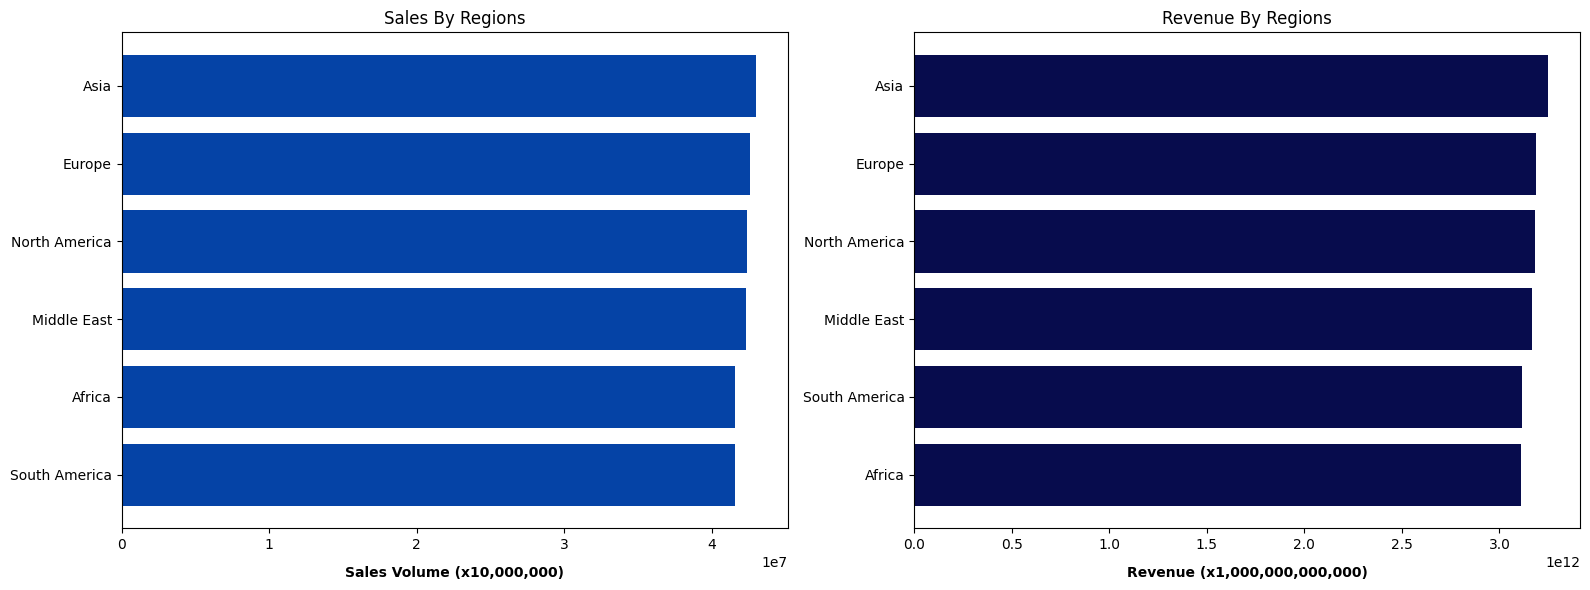

In [331]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

region_data.sort_values(by='sales_volume', inplace=True)
ax[0].barh(region_data['region'], region_data['sales_volume'], color=chart_color)
region_data.sort_values(by='revenue', inplace=True)
ax[1].barh(region_data['region'], region_data['revenue'], color='#070c4d')
ax[1].set_title('Revenue By Regions')
ax[0].set_title('Sales By Regions')
ax[0].set_xlabel('Sales Volume (x10,000,000)', fontweight='bold', labelpad=10)
ax[1].set_xlabel('Revenue (x1,000,000,000,000)', fontweight='bold', labelpad=10)


plt.tight_layout()
plt.show()

In [332]:
region_data

,region,revenue,sales_volume
0,Africa,3108999419352,41565252
5,South America,3113805414620,41551818
3,Middle East,3167783530851,42326620
4,North America,3182938635076,42402629
2,Europe,3188079573212,42555138
1,Asia,3250635961348,42974277


In [336]:
region_data['total_revenue'] = region_data['revenue'].sum()
region_data['total_sales'] = region_data['sales_volume'].sum()

In [ ]:

region_data

,region,revenue,sales_volume,total_sales,total_revenue
0,Africa,3108999419352,41565252,253375734,19012242534459
5,South America,3113805414620,41551818,253375734,19012242534459
3,Middle East,3167783530851,42326620,253375734,19012242534459
4,North America,3182938635076,42402629,253375734,19012242534459
2,Europe,3188079573212,42555138,253375734,19012242534459
1,Asia,3250635961348,42974277,253375734,19012242534459


**Calculate Percentage sales and Revenue Contribution per region**

In [346]:
region_data['percent_sales_contr'] = round((100 * region_data['sales_volume']/ region_data['total_sales']), 2)
region_data['percent_revenue_contr'] = round((100 * region_data['revenue']/ region_data['total_revenue']), 2)

In [ ]:
region_data

,region,revenue,sales_volume,total_sales,total_revenue,percent_sales_contr,percent_revenue_contr
0,Africa,3108999419352,41565252,253375734,19012242534459,16.40,16.35
5,South America,3113805414620,41551818,253375734,19012242534459,16.40,16.38
3,Middle East,3167783530851,42326620,253375734,19012242534459,16.71,16.66
4,North America,3182938635076,42402629,253375734,19012242534459,16.74,16.74
2,Europe,3188079573212,42555138,253375734,19012242534459,16.80,16.77
1,Asia,3250635961348,42974277,253375734,19012242534459,16.96,17.10


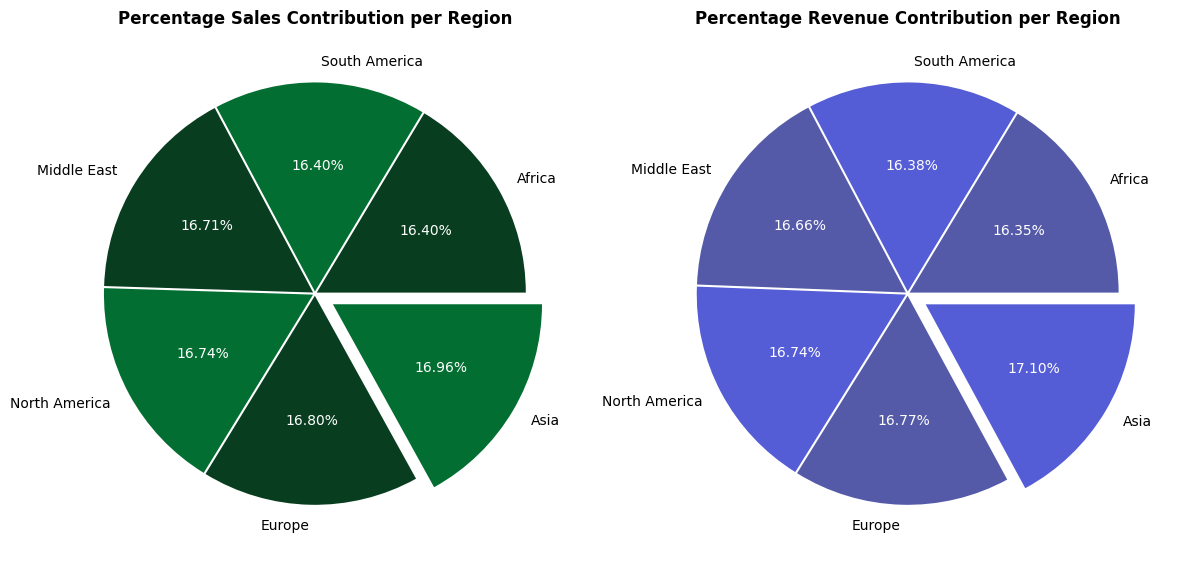

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[1].pie(region_data['percent_revenue_contr'], 
          autopct='%.2f%%', labels=region_data['region'],
            explode=[0.01,0.01,0.01,0.01,0.01,0.1],
          colors= ['#545aa8', '#545cd6'])

ax[0].pie(region_data['percent_sales_contr'],
           autopct='%.2f%%', labels=region_data['region'], 
           explode=[0.01,0.01,0.01,0.01,0.01,0.1],
           colors=['#083d1f', '#036e31'])


for chart in ax:
    for text in chart.texts:  
        if '%' in text.get_text():      
            text.set_color('white')      


ax[1].set_title('Percentage Revenue Contribution per Region', fontweight='bold')
ax[0].set_title('Percentage Sales Contribution per Region', fontweight='bold')
plt.tight_layout()
plt.show()